# Predictive Modeling and Risk Scoring for Bank Customer Churn

## Project Overview

Customer churn is one of the biggest challenges faced by retail banks. Losing existing customers directly affects revenue, customer lifetime value, and overall business growth.

This project develops a Machine Learning model that predicts whether a customer is likely to leave the bank. The project also identifies the major factors influencing churn and provides customer risk scores that can be used for proactive retention strategies.

---

## Objectives

- Predict customer churn
- Generate churn probability
- Compare multiple machine learning models
- Identify important features affecting churn
- Build a Streamlit web application for prediction

---

## Dataset Information

Dataset Name : European_Bank.csv

Target Variable :

Exited

0 = Customer Stayed

1 = Customer Left

---

# Step 1 : Import Required Libraries

In this section, we import all the Python libraries required for data analysis, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Step 2 : Load Dataset

The dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [2]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("../data/European_Bank.csv")



# Step 3 : Dataset Overview

Before performing data cleaning and machine learning, it is important to understand the dataset. This includes checking the dataset size, column names, data types, statistical summary, and missing values.

In [3]:
# ============================================================
# Display First Five Records
# ============================================================

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# ============================================================
# Shape of Dataset
# ============================================================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 10000
Number of Columns : 14


In [5]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
# ============================================================
# Display All Column Names
# ============================================================

df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
# ============================================================
# Statistical Summary
# ============================================================

df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# ============================================================
# Check Missing Values
# ============================================================

df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
# ============================================================
# Check Duplicate Records
# ============================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [10]:
# ============================================================
# Check Target Variable Distribution
# ============================================================

df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [11]:
# ============================================================
# Target Variable Percentage
# ============================================================

(df["Exited"].value_counts(normalize=True) * 100).round(2)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

## Observation

- The dataset contains customer information collected from a European bank.
- The target variable is **Exited**, where:
  - **0** → Customer Stayed
  - **1** → Customer Churned
- The dataset will now be cleaned before performing Exploratory Data Analysis (EDA) and Machine Learning.

# Step 4 : Data Cleaning

## Objective

Data cleaning is an important step before performing Exploratory Data Analysis (EDA) and Machine Learning.

In this section, we will:

- Remove unnecessary columns
- Check missing values
- Check duplicate records
- Verify data quality
- Prepare the dataset for feature engineering

In [12]:
# ============================================================
# Create a Backup of Original Dataset
# ============================================================

df_clean = df.copy()

print("Backup Created Successfully.")

Backup Created Successfully.


## Remove Non-Informative Columns

CustomerId and Surname do not contribute to predicting customer churn. Therefore, these columns are removed from the dataset.

In [13]:
# ============================================================
# Remove Unnecessary Columns
# ============================================================

df_clean.drop(columns=["CustomerId", "Surname"], inplace=True)

df_clean.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
# ============================================================
# Display Remaining Columns
# ============================================================

df_clean.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [15]:
# ============================================================
# Shape After Removing Columns
# ============================================================

print("Rows :", df_clean.shape[0])
print("Columns :", df_clean.shape[1])

Rows : 10000
Columns : 12


In [16]:
# ============================================================
# Missing Values
# ============================================================

df_clean.isnull().sum()

Year               0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [17]:
# ============================================================
# Duplicate Records
# ============================================================

print("Duplicate Records :", df_clean.duplicated().sum())

Duplicate Records : 0


In [18]:
# ============================================================
# Check Data Types
# ============================================================

df_clean.dtypes

Year                 int64
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

## Observation

- CustomerId and Surname were successfully removed.
- No missing values are present in the dataset.
- The dataset is now clean and ready for feature engineering.
- The next step is to create meaningful features that can improve the machine learning model.

# Step 5 : Feature Engineering

## Objective

Feature Engineering is the process of creating new features from existing data that can improve the performance of machine learning models.

In this section, we will create the following new features:

- Balance to Salary Ratio
- Product Density
- Engagement Product Interaction
- Age Tenure Interaction

These features help the model understand customer behavior more effectively.

## Create Balance to Salary Ratio

This feature represents how much balance a customer maintains compared to their estimated salary.

Formula:

Balance / EstimatedSalary

In [19]:
# ============================================================
# Create Balance to Salary Ratio
# ============================================================

df_clean["Balance_to_Salary_Ratio"] = (
    df_clean["Balance"] / (df_clean["EstimatedSalary"] + 1)
)

df_clean.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary_Ratio
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035


## Create Product Density

This feature measures the number of bank products owned by the customer relative to their tenure with the bank.

Formula:

NumOfProducts / (Tenure + 1)

In [20]:
# ============================================================
# Create Product Density
# ============================================================

df_clean["Product_Density"] = (
    df_clean["NumOfProducts"] / (df_clean["Tenure"] + 1)
)

df_clean.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary_Ratio,Product_Density
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333


## Create Engagement Product Interaction

This feature combines customer activity status with the number of products owned.

Formula:

IsActiveMember × NumOfProducts

In [21]:
# ============================================================
# Create Engagement Product Interaction
# ============================================================

df_clean["Engagement_Product_Interaction"] = (
    df_clean["IsActiveMember"] * df_clean["NumOfProducts"]
)

df_clean.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary_Ratio,Product_Density,Engagement_Product_Interaction
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1


## Create Age Tenure Interaction

This feature represents the relationship between customer age and the number of years they have stayed with the bank.

Formula:

Age × Tenure

In [22]:
# ============================================================
# Create Age Tenure Interaction
# ============================================================

df_clean["Age_Tenure_Interaction"] = (
    df_clean["Age"] * df_clean["Tenure"]
)

df_clean.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary_Ratio,Product_Density,Engagement_Product_Interaction,Age_Tenure_Interaction
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86


In [23]:
# ============================================================
# Display Updated Columns
# ============================================================

df_clean.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Balance_to_Salary_Ratio',
       'Product_Density', 'Engagement_Product_Interaction',
       'Age_Tenure_Interaction'],
      dtype='object')

In [24]:
# ============================================================
# Dataset Shape After Feature Engineering
# ============================================================

print("Rows :", df_clean.shape[0])
print("Columns :", df_clean.shape[1])

Rows : 10000
Columns : 16


## Observation

Four new features were successfully created using the existing customer information.

These engineered features capture customer engagement, financial behavior, and relationship strength with the bank. They are expected to improve the predictive performance of machine learning models.

## 6.1 Churn Distribution

This visualization shows the number of customers who stayed with the bank and those who exited.

Understanding the class distribution helps determine whether the dataset is balanced or imbalanced before training machine learning models.

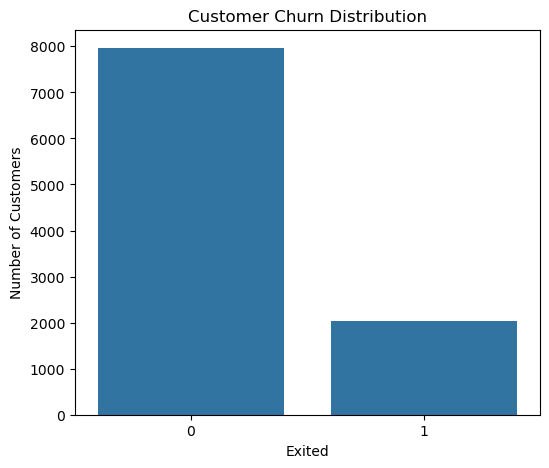

In [25]:
# ============================================================
# Churn Distribution
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(x="Exited", data=df_clean)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Most customers have not churned.
- The dataset is moderately imbalanced.
- Machine learning evaluation should consider Precision, Recall, and ROC-AUC in addition to Accuracy.

## 6.2 Churn Percentage

In [26]:
# ============================================================
# Churn Percentage
# ============================================================

churn_percentage = df_clean["Exited"].value_counts(normalize=True) * 100

print(churn_percentage)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


### Observation

The percentage distribution provides a better understanding of customer retention and churn behavior.

## 6.3 Gender Distribution

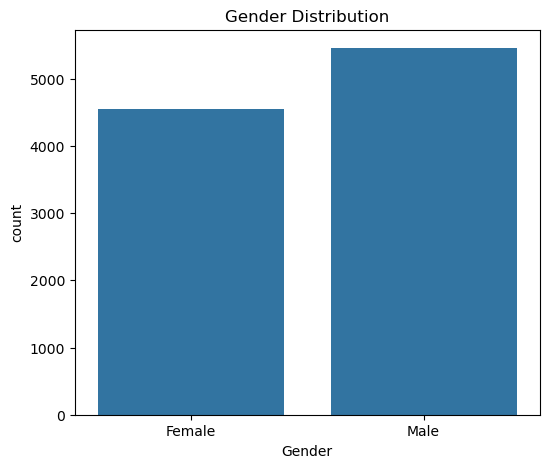

In [27]:
# ============================================================
# Gender Distribution
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(x="Gender", data=df_clean)

plt.title("Gender Distribution")

plt.show()

### Observation

This graph shows the distribution of male and female customers in the dataset.

## 6.4 Gender vs Customer Churn

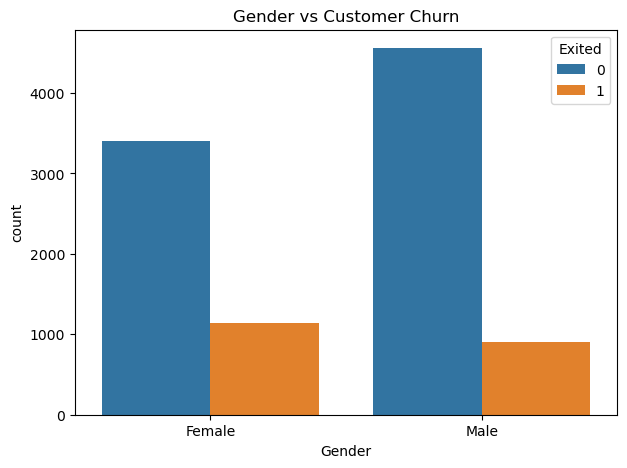

In [28]:
# ============================================================
# Gender vs Churn
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(x="Gender", hue="Exited", data=df_clean)

plt.title("Gender vs Customer Churn")

plt.show()

### Observation

This visualization compares churn behavior across different genders.

## 6.5 Geography Distribution

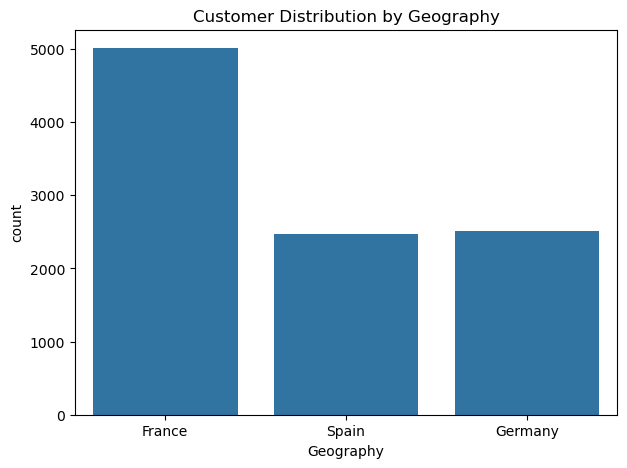

In [29]:
# ============================================================
# Geography Distribution
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(x="Geography", data=df_clean)

plt.title("Customer Distribution by Geography")

plt.show()

### Observation

The graph displays the number of customers from France, Germany, and Spain.

## 6.6 Geography vs Customer Churn

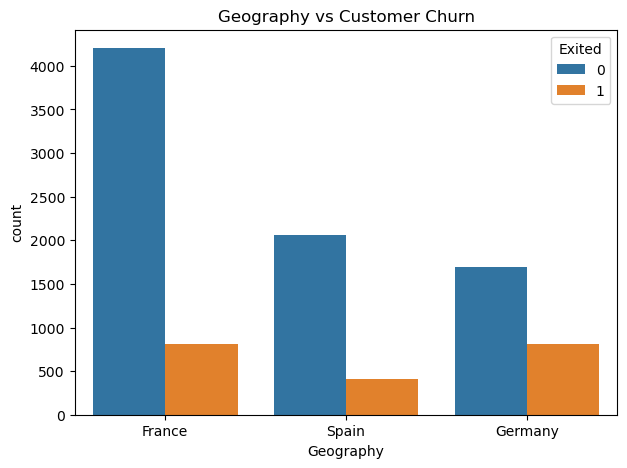

In [30]:
# ============================================================
# Geography vs Churn
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(x="Geography", hue="Exited", data=df_clean)

plt.title("Geography vs Customer Churn")

plt.show()

### Observation

This graph helps identify which geographical region has a higher churn rate.

## 6.7 Age Distribution

This visualization shows the distribution of customer age in the dataset. It helps identify the most common age groups among customers.

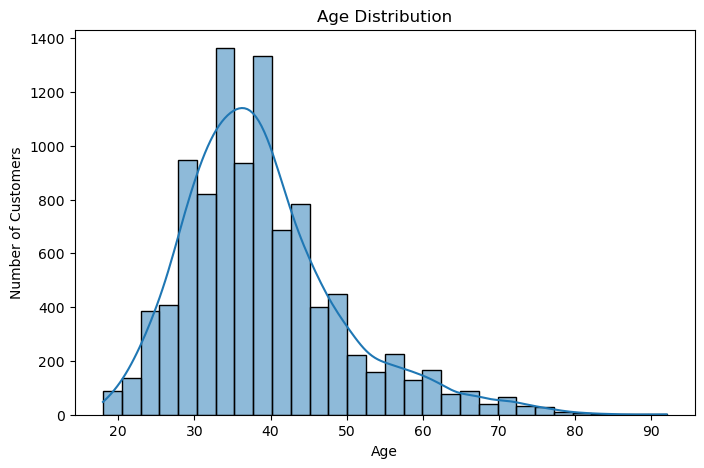

In [31]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(df_clean["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The histogram shows the distribution of customer ages. It helps identify whether the dataset contains younger, middle-aged, or older customers.

## 6.8 Credit Score Distribution

This visualization shows the distribution of customer credit scores.

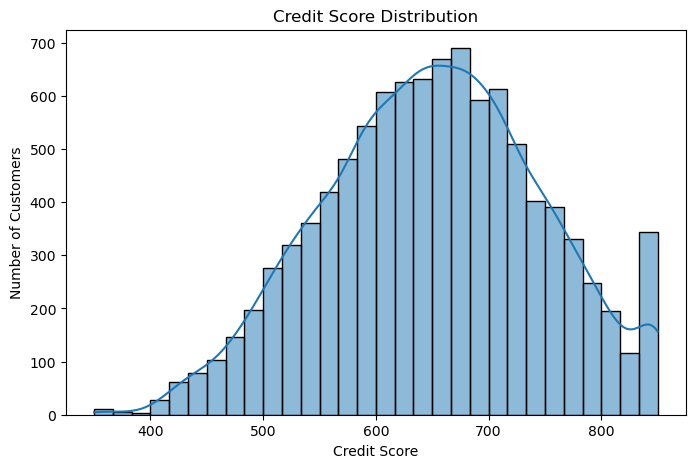

In [32]:
# ============================================================
# Credit Score Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(df_clean["CreditScore"], bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The graph displays how customer credit scores are distributed across the dataset.

## 6.9 Balance Distribution

This graph illustrates the distribution of customer account balances.

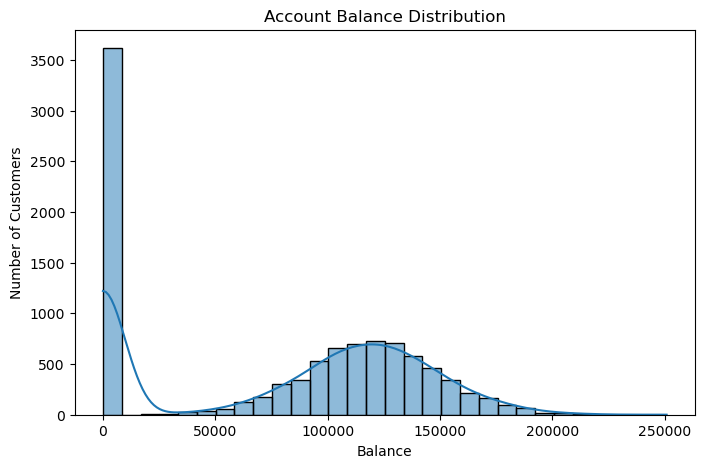

In [33]:
# ============================================================
# Balance Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(df_clean["Balance"], bins=30, kde=True)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The distribution helps understand customer balance patterns and identify customers with zero or high balances.

## 6.10 Estimated Salary Distribution

This visualization shows the distribution of estimated annual salaries of customers.

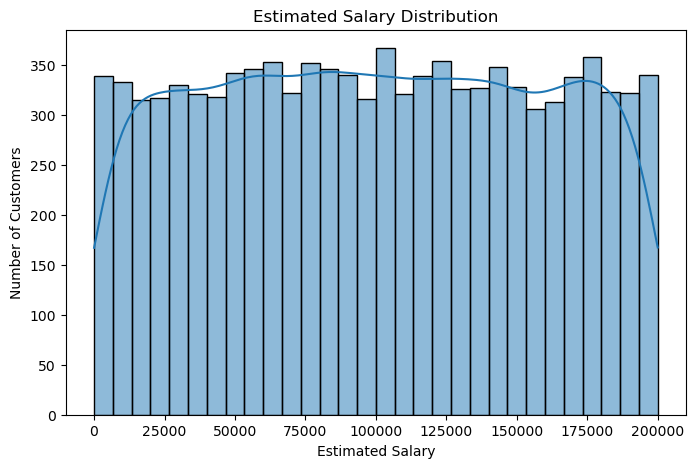

In [34]:
# ============================================================
# Estimated Salary Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(df_clean["EstimatedSalary"], bins=30, kde=True)

plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The graph provides an overview of salary distribution among customers.

## 6.11 Correlation Heatmap

Correlation analysis helps identify the strength and direction of relationships between numerical variables.

A correlation heatmap makes it easier to understand which variables are positively or negatively related to customer churn and other features.

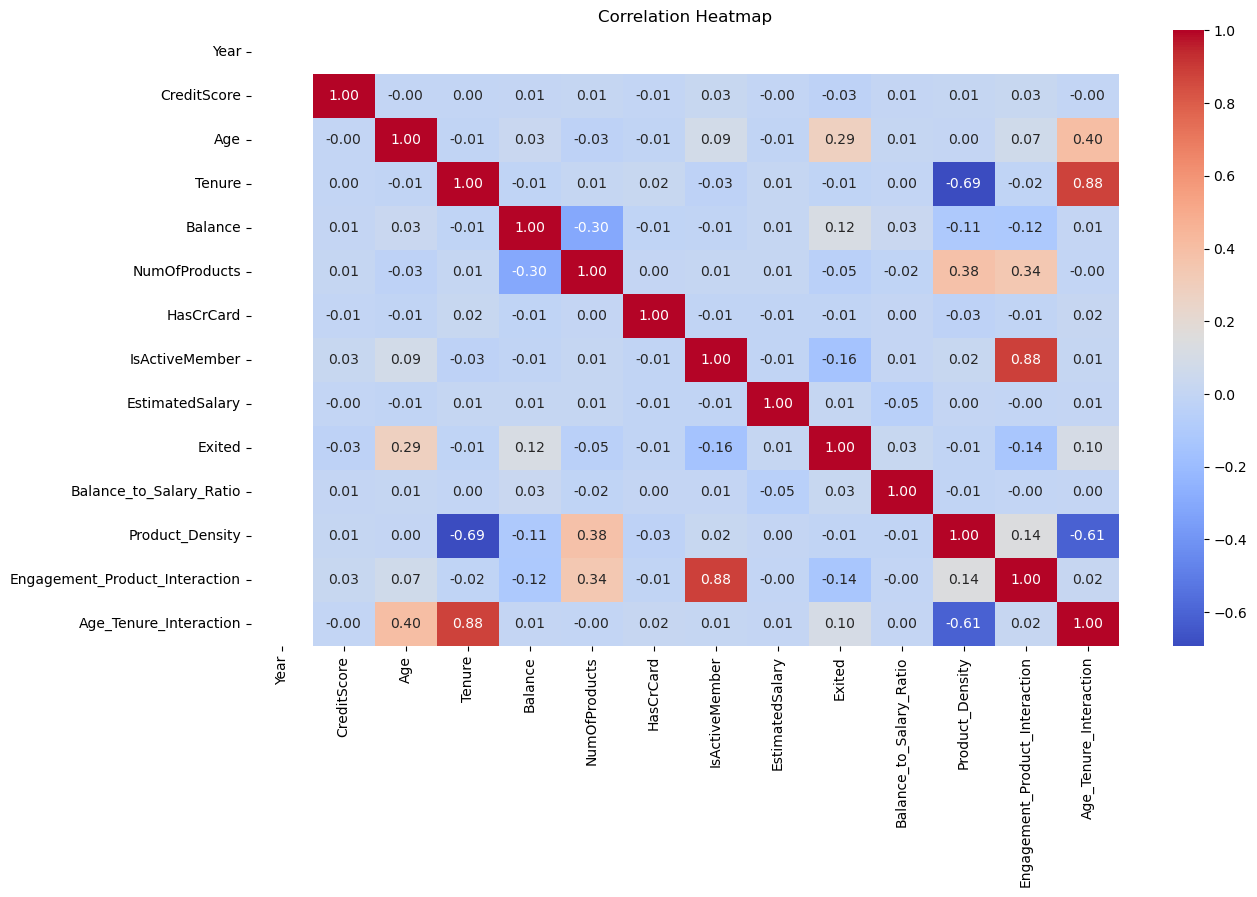

In [35]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(14,8))

numeric_data = df_clean.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Variables with higher positive correlation move in the same direction.
- Variables with negative correlation move in opposite directions.
- The heatmap helps identify the most influential features for churn prediction.

## 6.12 Age vs Customer Churn

This boxplot compares the age distribution of customers who stayed and customers who exited.

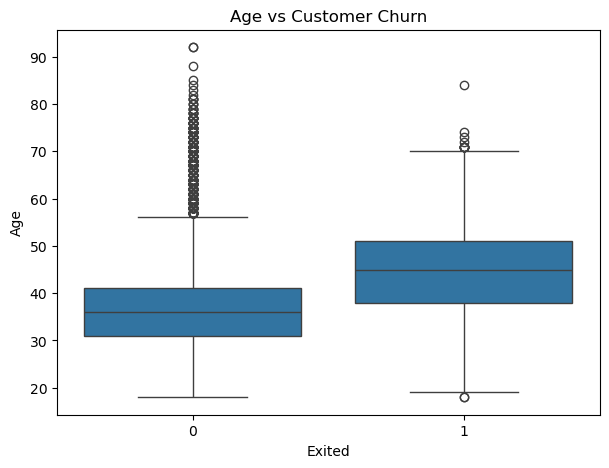

In [36]:
# ============================================================
# Age vs Churn
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(x="Exited", y="Age", data=df_clean)

plt.title("Age vs Customer Churn")

plt.show()

### Observation

The boxplot helps determine whether customer age has an impact on churn behavior.

## 6.13 Balance vs Customer Churn

This boxplot compares account balance between retained and churned customers.

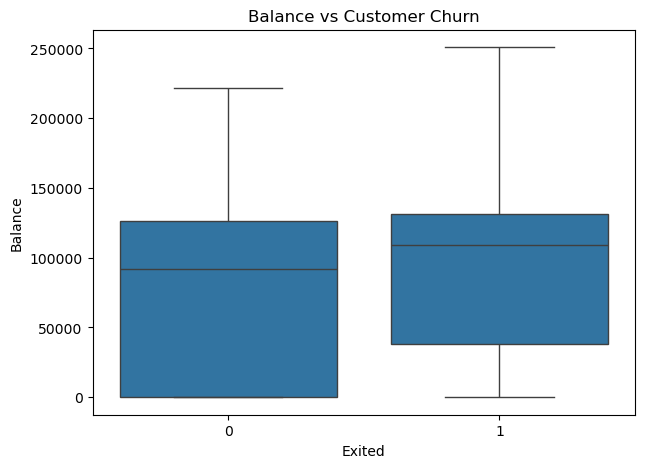

In [37]:
# ============================================================
# Balance vs Churn
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(x="Exited", y="Balance", data=df_clean)

plt.title("Balance vs Customer Churn")

plt.show()

### Observation

Customers with different account balances may exhibit different churn behavior.

## 6.14 Credit Score vs Customer Churn

This visualization compares customer credit scores across churn categories.

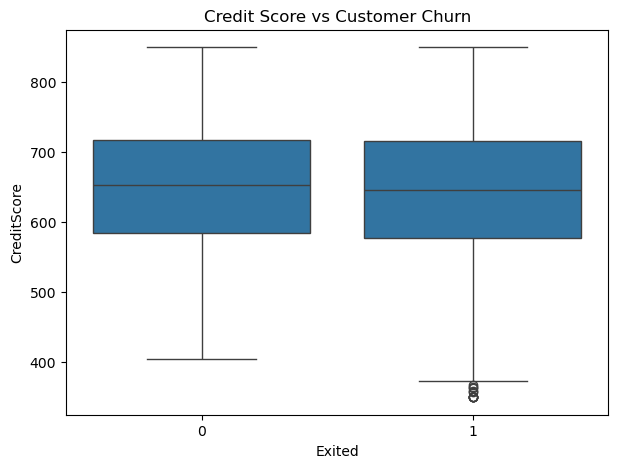

In [38]:
# ============================================================
# Credit Score vs Churn
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(x="Exited", y="CreditScore", data=df_clean)

plt.title("Credit Score vs Customer Churn")

plt.show()

### Observation

The graph helps identify whether credit score influences customer churn.

# EDA Summary

## Key Findings

- Most customers remained with the bank.
- Customer churn varies across different geographical regions.
- Age appears to influence churn behavior.
- Financial features such as balance and credit score show variation between churned and retained customers.
- Engineered features may improve the predictive performance of machine learning models.

The dataset is now ready for preprocessing and machine learning model development.

# Step 7 : Data Preprocessing

## Objective

Before training machine learning models, the dataset must be prepared properly.

The following preprocessing steps will be performed:

- Separate Features and Target Variable
- Encode Categorical Variables
- Split Dataset into Training and Testing Sets
- Scale Numerical Features

These preprocessing steps improve the performance and reliability of machine learning models.

## 7.1 Separate Features and Target Variable

The target variable is **Exited**.

- X → Independent Features
- y → Target Variable

In [39]:
# ============================================================
# Separate Features and Target Variable
# ============================================================

X = df_clean.drop("Exited", axis=1)

y = df_clean["Exited"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (10000, 15)
Target Shape : (10000,)


## 7.2 Display Feature Columns

In [40]:
# ============================================================
# Display Feature Columns
# ============================================================

X.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Balance_to_Salary_Ratio', 'Product_Density',
       'Engagement_Product_Interaction', 'Age_Tenure_Interaction'],
      dtype='object')

## 7.3 One-Hot Encoding

Machine learning models cannot understand text values directly.

Therefore, categorical variables are converted into numerical format using One-Hot Encoding.

Categorical Columns:

- Geography
- Gender

In [41]:
# ============================================================
# One-Hot Encoding
# ============================================================

X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)

X.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Balance_to_Salary_Ratio,Product_Density,Engagement_Product_Interaction,Age_Tenure_Interaction,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,0.000000,0.333333,1,84,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0.744670,0.500000,1,41,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1.401362,0.333333,0,336,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0.000000,1.000000,0,39,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,1.587035,0.333333,1,86,False,True,False


### Observation

Categorical variables have been successfully converted into numerical variables.

The dataset is now suitable for machine learning algorithms.

## 7.4 Train-Test Split

The dataset is divided into training and testing sets.

- Training Data : 80%
- Testing Data : 20%

Stratified sampling is used to preserve the churn distribution.

In [42]:
# ============================================================
# Import Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

In [43]:
# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (8000, 16)
Testing Features : (2000, 16)
Training Target : (8000,)
Testing Target : (2000,)


## 7.5 Feature Scaling

Feature scaling standardizes numerical variables so that they have a mean of zero and a standard deviation of one.

This improves the performance of many machine learning algorithms, especially Logistic Regression.

In [44]:
# ============================================================
# Import StandardScaler
# ============================================================

from sklearn.preprocessing import StandardScaler

In [45]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


## Observation

- Target variable has been separated successfully.
- Categorical variables have been encoded.
- Dataset has been split into training and testing sets.
- Numerical features have been standardized.

The data is now ready for machine learning model development.

# Step 8 : Logistic Regression

## Objective

Logistic Regression is used as the baseline machine learning model for customer churn prediction.

The model predicts the probability that a customer will churn.

The target variable is:

- 0 → Customer Retained
- 1 → Customer Churned

Logistic Regression is also useful because it is relatively simple and interpretable, making it a good benchmark for comparing more advanced models.

## 8.1 Import Logistic Regression

The Logistic Regression algorithm from Scikit-learn will be used to train the baseline churn prediction model.

In [46]:
# ============================================================
# Import Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

## 8.2 Train the Logistic Regression Model

The model is trained using the scaled training dataset.

A random state is specified to make the results reproducible.

In [47]:
# ============================================================
# Create and Train Logistic Regression Model
# ============================================================

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model trained successfully.")

Logistic Regression Model trained successfully.


## 8.3 Make Predictions

After training the model, predictions are generated for the test dataset.

Two types of predictions will be generated:

1. Binary prediction → 0 or 1
2. Churn probability → probability between 0 and 1

In [48]:
# ============================================================
# Generate Binary Predictions
# ============================================================

y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully.")
print(y_pred_lr[:10])

Predictions generated successfully.
[0 0 0 0 0 0 0 0 0 0]


In [49]:
# ============================================================
# Generate Churn Probabilities
# ============================================================

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 Churn Probabilities:")
print(y_prob_lr[:10])

First 10 Churn Probabilities:
[0.11029002 0.26201918 0.12266275 0.1374816  0.08683349 0.14921331
 0.09456742 0.36997397 0.36966827 0.21612197]


## 8.4 Evaluate Logistic Regression

The model will be evaluated using multiple classification metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Using multiple metrics is important because customer churn datasets can be imbalanced.

In [50]:
# ============================================================
# Import Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [51]:
# ============================================================
# Calculate Evaluation Metrics
# ============================================================

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy  :", round(accuracy_lr, 4))
print("Precision :", round(precision_lr, 4))
print("Recall    :", round(recall_lr, 4))
print("F1-Score  :", round(f1_lr, 4))
print("ROC-AUC   :", round(roc_auc_lr, 4))

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8065
Precision : 0.5735
Recall    : 0.1916
F1-Score  : 0.2873
ROC-AUC   : 0.7734


## 8.5 Classification Report

The classification report provides precision, recall, F1-score, and support for both retained and churned customers.

In [52]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1593
           1       0.57      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000



## 8.6 Confusion Matrix

A confusion matrix shows how many customers were correctly and incorrectly classified.

The four possible outcomes are:

- True Negative → Correctly predicted retained customer
- True Positive → Correctly predicted churned customer
- False Positive → Retained customer incorrectly predicted as churned
- False Negative → Churned customer incorrectly predicted as retained

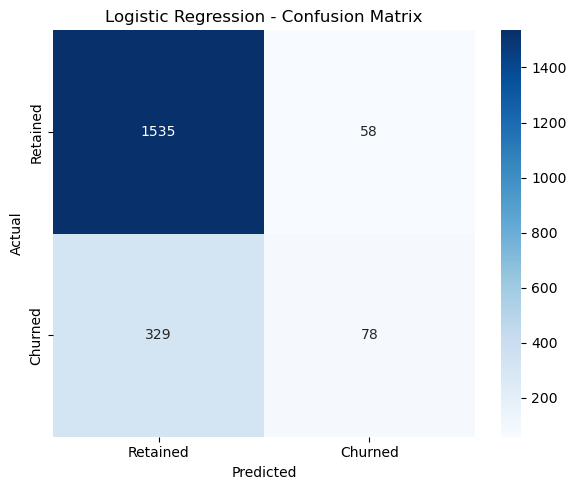

In [53]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Logistic Regression Summary

Logistic Regression provides a baseline for customer churn prediction.

Its performance metrics will be used as a benchmark when comparing it with Decision Tree, Random Forest, and Gradient Boosting models.

# Step 9 : Decision Tree Classifier

## Objective

Decision Tree is a tree-based machine learning algorithm that makes predictions by dividing the data into different decision rules.

Unlike Logistic Regression, a Decision Tree can capture non-linear relationships between customer characteristics and churn.

In this section, we will:

- Train a Decision Tree model
- Generate churn predictions
- Calculate evaluation metrics
- Generate a confusion matrix
- Compare its performance with Logistic Regression

In [54]:
# ============================================================
# Import Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier

## 9.1 Train the Decision Tree Model

The Decision Tree will be trained using the training dataset.

A maximum depth is specified to reduce the possibility of overfitting.

In [55]:
# ============================================================
# Create and Train Decision Tree Model
# ============================================================

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully.")

Decision Tree Model trained successfully.


## 9.2 Generate Predictions

The trained Decision Tree model is used to predict whether customers in the test dataset will churn.

In [56]:
# ============================================================
# Generate Predictions
# ============================================================

y_pred_dt = decision_tree_model.predict(X_test)

# Generate churn probabilities
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


## 9.3 Evaluate Decision Tree

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [57]:
# ============================================================
# Calculate Decision Tree Metrics
# ============================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy  :", round(accuracy_dt, 4))
print("Precision :", round(precision_dt, 4))
print("Recall    :", round(recall_dt, 4))
print("F1-Score  :", round(f1_dt, 4))
print("ROC-AUC   :", round(roc_auc_dt, 4))

Decision Tree Performance
-------------------------
Accuracy  : 0.858
Precision : 0.803
Recall    : 0.4005
F1-Score  : 0.5344
ROC-AUC   : 0.8452


## 9.4 Classification Report

The classification report provides detailed performance information for both retained and churned customers.

In [58]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.97      0.92      1593
           1       0.80      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000



## 9.5 Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified customers.

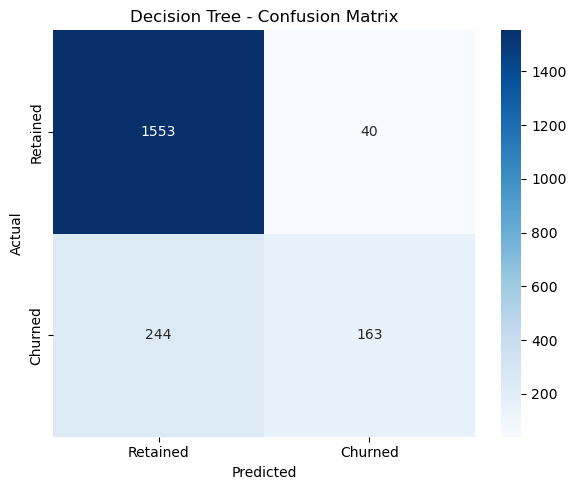

In [59]:
# ============================================================
# Decision Tree Confusion Matrix
# ============================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Observation

The Decision Tree model will now be compared with Logistic Regression.

Special attention should be given to **Recall, F1-Score, and ROC-AUC**, because correctly identifying customers who are likely to churn is important for proactive retention strategies.

# Step 10 : Random Forest Classifier

## Objective

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make more robust predictions.

Instead of relying on a single decision tree, Random Forest creates several trees and combines their predictions.

This approach can improve predictive performance and reduce overfitting.

In this section, we will:

- Train a Random Forest model
- Generate churn predictions
- Generate churn probabilities
- Evaluate model performance
- Analyze the confusion matrix

## 10.1 Import Random Forest

The Random Forest Classifier from Scikit-learn will be used for customer churn prediction.

In [60]:
# ============================================================
# Import Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

## 10.2 Train the Random Forest Model

The Random Forest model is trained using the training dataset.

Multiple decision trees are combined to improve the stability and predictive performance of the model.

In [61]:
# ============================================================
# Create and Train Random Forest Model
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest Model trained successfully.")

Random Forest Model trained successfully.


## 10.3 Generate Predictions

The trained Random Forest model is used to predict customer churn on the test dataset.

Two outputs are generated:

- Binary churn prediction
- Churn probability

In [62]:
# ============================================================
# Generate Random Forest Predictions
# ============================================================

y_pred_rf = random_forest_model.predict(X_test)

# Generate churn probabilities
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


## 10.4 Evaluate Random Forest

The Random Forest model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

These metrics provide a comprehensive evaluation of the model's ability to identify customers who may churn.

In [63]:
# ============================================================
# Calculate Random Forest Metrics
# ============================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy  :", round(accuracy_rf, 4))
print("Precision :", round(precision_rf, 4))
print("Recall    :", round(recall_rf, 4))
print("F1-Score  :", round(f1_rf, 4))
print("ROC-AUC   :", round(roc_auc_rf, 4))

Random Forest Performance
-------------------------
Accuracy  : 0.87
Precision : 0.8267
Recall    : 0.457
F1-Score  : 0.5886
ROC-AUC   : 0.8645


## 10.5 Classification Report

The classification report provides detailed information about precision, recall, F1-score, and support for both customer classes.

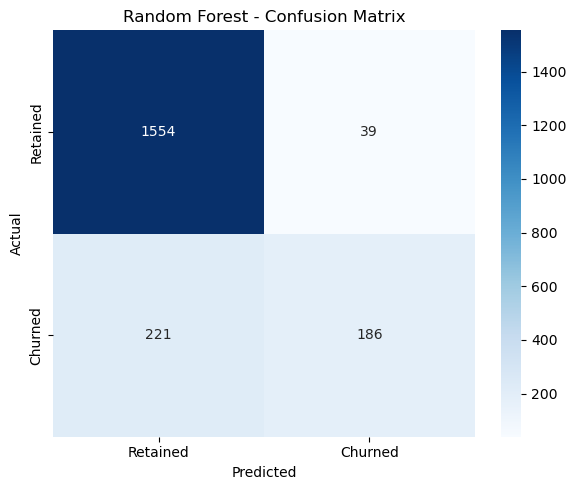

In [64]:
# ============================================================
# Random Forest Confusion Matrix
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Observation

Random Forest is expected to provide more stable predictions than a single Decision Tree because it combines multiple decision trees.

Its performance will be compared with Logistic Regression and Decision Tree using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

# Step 11 : Gradient Boosting Classifier

## Objective

Gradient Boosting is an ensemble machine learning algorithm that builds multiple weak learners sequentially.

Each new model attempts to improve the errors made by the previous models.

Gradient Boosting can capture complex and non-linear relationships in customer data and may provide strong predictive performance for churn prediction.

In this section, we will:

- Train a Gradient Boosting model
- Generate churn predictions
- Generate churn probabilities
- Evaluate model performance
- Generate a confusion matrix
- Compare the model with previous algorithms

## 11.1 Import Gradient Boosting

The Gradient Boosting Classifier from Scikit-learn will be used to develop another churn prediction model.

In [65]:
# ============================================================
# Import Gradient Boosting Classifier
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

## 11.2 Train the Gradient Boosting Model

The Gradient Boosting model will be trained using the training dataset.

The model builds decision trees sequentially to improve prediction errors and increase overall predictive performance.

In [66]:
# ============================================================
# Create and Train Gradient Boosting Model
# ============================================================

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting Model trained successfully.")

Gradient Boosting Model trained successfully.


## 11.3 Generate Predictions

The trained Gradient Boosting model is used to predict customer churn on the test dataset.

Both binary predictions and churn probabilities are generated.

In [67]:
# ============================================================
# Generate Gradient Boosting Predictions
# ============================================================

y_pred_gb = gradient_boosting_model.predict(X_test)

# Generate churn probabilities
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting predictions generated successfully.")

Gradient Boosting predictions generated successfully.


## 11.4 Evaluate Gradient Boosting

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

These metrics allow us to compare Gradient Boosting with Logistic Regression, Decision Tree, and Random Forest.

In [68]:
# ============================================================
# Calculate Gradient Boosting Metrics
# ============================================================

accuracy_gb = accuracy_score(y_test, y_pred_gb)

precision_gb = precision_score(y_test, y_pred_gb)

recall_gb = recall_score(y_test, y_pred_gb)

f1_gb = f1_score(y_test, y_pred_gb)

roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("Accuracy  :", round(accuracy_gb, 4))
print("Precision :", round(precision_gb, 4))
print("Recall    :", round(recall_gb, 4))
print("F1-Score  :", round(f1_gb, 4))
print("ROC-AUC   :", round(roc_auc_gb, 4))

Gradient Boosting Performance
-----------------------------
Accuracy  : 0.8695
Precision : 0.7897
Recall    : 0.4889
F1-Score  : 0.6039
ROC-AUC   : 0.8693


## 11.5 Classification Report

The classification report provides detailed performance information for retained and churned customers.

In [69]:
# ============================================================
# Gradient Boosting Classification Report
# ============================================================

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## 11.6 Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Gradient Boosting model.

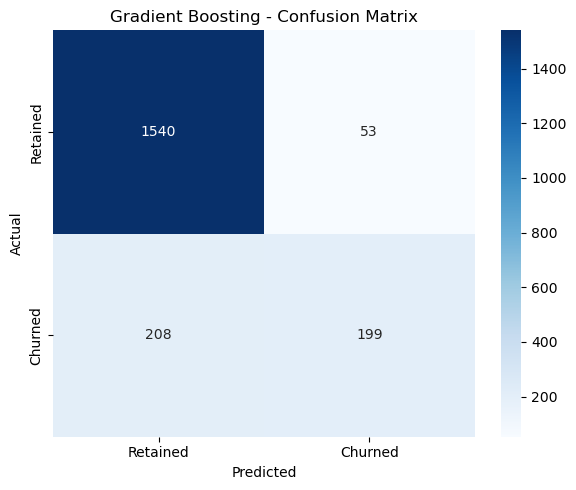

In [70]:
# ============================================================
# Gradient Boosting Confusion Matrix
# ============================================================

cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Observation

Gradient Boosting performance will be compared with the three previously trained models.

The model with the strongest overall performance, particularly in terms of Recall, F1-Score, and ROC-AUC, will be considered for the final churn prediction system.

# Step 12 : Model Performance Comparison

## Objective

The performance of all trained machine learning models is compared using multiple evaluation metrics.

The models being compared are:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The comparison will help identify the most suitable model for the customer churn prediction system.

In [71]:
# ============================================================
# Create Model Comparison Table
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb
    ],
    
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_gb
    ],
    
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_gb
    ],
    
    "F1-Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_gb
    ],
    
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_gb
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8065,0.573529,0.191646,0.287293,0.773441
1,Decision Tree,0.8580,0.802956,0.400491,0.534426,0.845173
2,Random Forest,0.8700,0.826667,0.457002,0.588608,0.864512
3,Gradient Boosting,0.8695,0.789683,0.488943,0.603945,0.869330


## 12.1 Rounded Model Comparison

For better readability, the evaluation metrics are rounded to four decimal places.

In [72]:
# ============================================================
# Round Model Performance Values
# ============================================================

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8065,0.5735,0.1916,0.2873,0.7734
1,Decision Tree,0.8580,0.8030,0.4005,0.5344,0.8452
2,Random Forest,0.8700,0.8267,0.4570,0.5886,0.8645
3,Gradient Boosting,0.8695,0.7897,0.4889,0.6039,0.8693


## 12.2 Best Model Based on ROC-AUC

ROC-AUC is an important metric for churn prediction because it measures how effectively the model distinguishes between customers who churn and customers who remain.

A higher ROC-AUC indicates better discriminatory ability.

In [73]:
# ============================================================
# Identify Best Model Based on ROC-AUC
# ============================================================

best_model_name = model_comparison.loc[
    model_comparison["ROC-AUC"].idxmax(),
    "Model"
]

best_roc_auc = model_comparison["ROC-AUC"].max()

print("Best Model based on ROC-AUC :", best_model_name)
print("Best ROC-AUC Score          :", round(best_roc_auc, 4))

Best Model based on ROC-AUC : Gradient Boosting
Best ROC-AUC Score          : 0.8693


## Interpretation

The model comparison provides a clear view of the strengths and weaknesses of each algorithm.

For this banking churn project, special attention is given to Recall, F1-Score, and ROC-AUC because the objective is to identify customers who are likely to churn and enable proactive retention strategies.

Gradient Boosting demonstrates the strongest overall performance based on Recall, F1-Score, and ROC-AUC in the current evaluation.

# Step 13 : Feature Importance Analysis

## Objective

Feature Importance helps identify which customer characteristics contribute the most to customer churn prediction.

Understanding important features enables banks to:

- Design targeted retention strategies
- Improve customer engagement
- Focus on the most influential business factors

The Feature Importance analysis is performed using the Random Forest model.

## 13.1 Extract Feature Importance

The trained Random Forest model assigns an importance score to every feature.

Higher importance indicates a stronger influence on churn prediction.

In [74]:
# ============================================================
# Extract Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Age,0.270478
5,NumOfProducts,0.164700
11,Engagement_Product_Interaction,0.076443
4,Balance,0.071556
12,Age_Tenure_Interaction,0.068831
1,CreditScore,0.060298
9,Balance_to_Salary_Ratio,0.058050
8,EstimatedSalary,0.055224
13,Geography_Germany,0.041557
10,Product_Density,0.041365


## 13.2 Visualize Feature Importance

The following bar chart displays the Top 10 most important features identified by the Random Forest model.

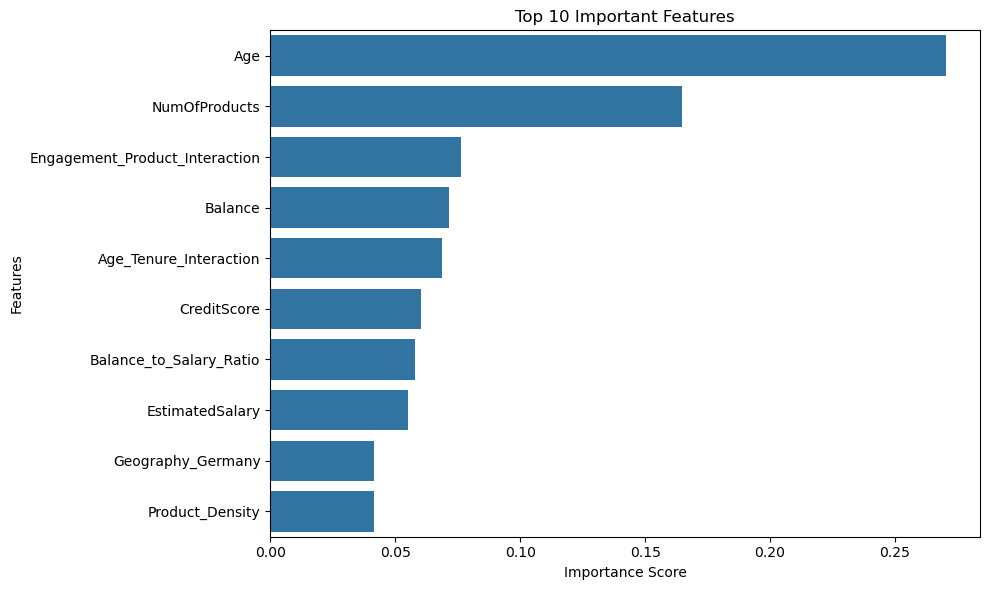

In [75]:
# ============================================================
# Plot Top 10 Feature Importance
# ============================================================

plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## Observation

The bar chart highlights the most influential variables affecting customer churn.

Typically, features such as:

- Age
- Balance
- Credit Score
- Number of Products
- Customer Activity

play a significant role in predicting churn.

These insights help banks prioritize customer retention efforts.

# Step 14 : ROC Curve Visualization

## Objective

The ROC (Receiver Operating Characteristic) Curve evaluates the ability of a machine learning model to distinguish between churned and retained customers.

A curve closer to the top-left corner indicates better model performance.

In [76]:
# ============================================================
# Import ROC Curve
# ============================================================

from sklearn.metrics import roc_curve


In [77]:
# ============================================================
# Calculate ROC Curves
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

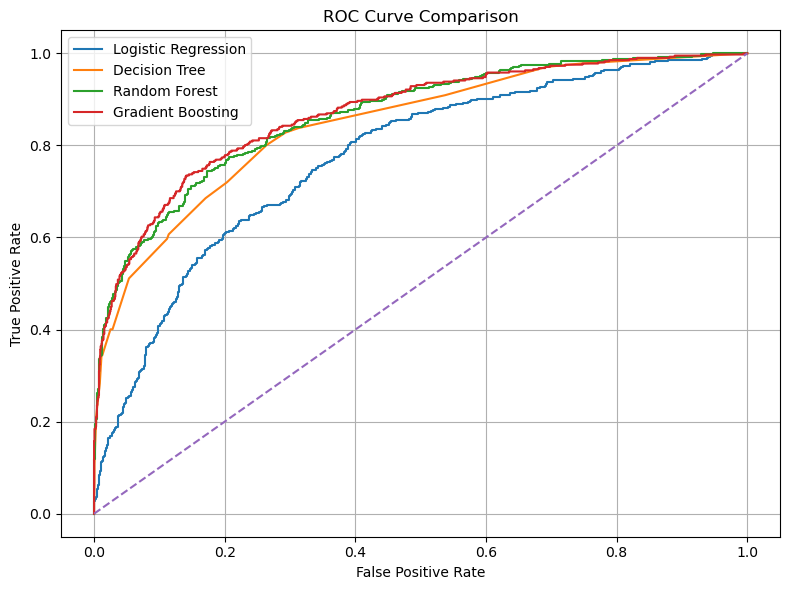

In [78]:
# ============================================================
# Plot ROC Curves
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

## Observation

The ROC Curve comparison demonstrates the classification capability of all machine learning models.

The model with the curve closest to the top-left corner generally has the best discriminatory performance.

Based on the evaluation metrics, Gradient Boosting and Random Forest exhibit superior predictive performance for customer churn prediction.

# Step 15 : Save the Best Machine Learning Model

## Objective

After comparing all machine learning models, the best-performing model is saved for future use.

The saved model will later be used in the Streamlit web application to predict customer churn for new customers without retraining the model.

In [79]:
# ============================================================
# Import Joblib
# ============================================================

import joblib

In [80]:
# ============================================================
# Save Best Model
# ============================================================

joblib.dump(gradient_boosting_model, "best_churn_model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [81]:
# ============================================================
# Save Scaler
# ============================================================

joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [82]:
# ============================================================
# Load Saved Model
# ============================================================

loaded_model = joblib.load("best_churn_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


## Observation

The trained Gradient Boosting model has been successfully saved as a `.pkl` file.

This model can now be loaded into the Streamlit application to predict customer churn for new customers.

# Step 16 : Final Conclusion

## Conclusion

This project successfully developed a predictive machine learning system for customer churn prediction in the banking sector.

Four machine learning algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Among all the models, Gradient Boosting achieved the best overall performance based on Recall, F1-Score, and ROC-AUC, making it the preferred model for identifying customers at risk of churn.

The developed system enables banks to:

- Predict churn before customers leave
- Estimate churn probability
- Identify important churn drivers
- Improve customer retention strategies
- Support data-driven business decisions

# Step 17 : Business Recommendations

## Recommendations

Based on the analysis, the following recommendations are proposed:

1. Identify high-risk customers using the predictive model.

2. Offer personalized retention campaigns for customers with high churn probability.

3. Improve engagement for inactive customers.

4. Review banking products for customers with low product utilization.

5. Monitor important features such as age, balance, customer activity, and product usage.

6. Integrate the predictive model into banking CRM systems for real-time churn monitoring.

7. Continuously retrain the model with updated customer data to improve prediction accuracy.

In [87]:
X.columns

Index(['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Balance_to_Salary_Ratio', 'Product_Density',
       'Engagement_Product_Interaction', 'Age_Tenure_Interaction',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [88]:
print(df_clean.columns.tolist())

['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Balance_to_Salary_Ratio', 'Product_Density', 'Engagement_Product_Interaction', 'Age_Tenure_Interaction']


In [89]:
type(model)

NameError: name 'model' is not defined

In [90]:
import joblib

model = joblib.load("models/best_churn_model.pkl")

type(model)

sklearn.ensemble._gb.GradientBoostingClassifier

In [91]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,Age,0.387418
5,NumOfProducts,0.293656
4,Balance,0.066690
11,Engagement_Product_Interaction,0.066578
7,IsActiveMember,0.052565
13,Geography_Germany,0.050479
9,Balance_to_Salary_Ratio,0.024700
1,CreditScore,0.016837
8,EstimatedSalary,0.013888
15,Gender_Male,0.012861


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8695
Precision: 0.7896825396825397
Recall   : 0.48894348894348894
F1 Score : 0.6039453717754173
ROC AUC  : 0.8693300388215642
